In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as  plt
import seaborn as sns
import matplotlib.image as mping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [5]:
train=pd.read_csv("/kaggle/input/datasets/shwetakaliramana/mnist-dataset/train.csv")
test=pd.read_csv("/kaggle/input/datasets/shwetakaliramana/mnist-dataset/test.csv")

In [6]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

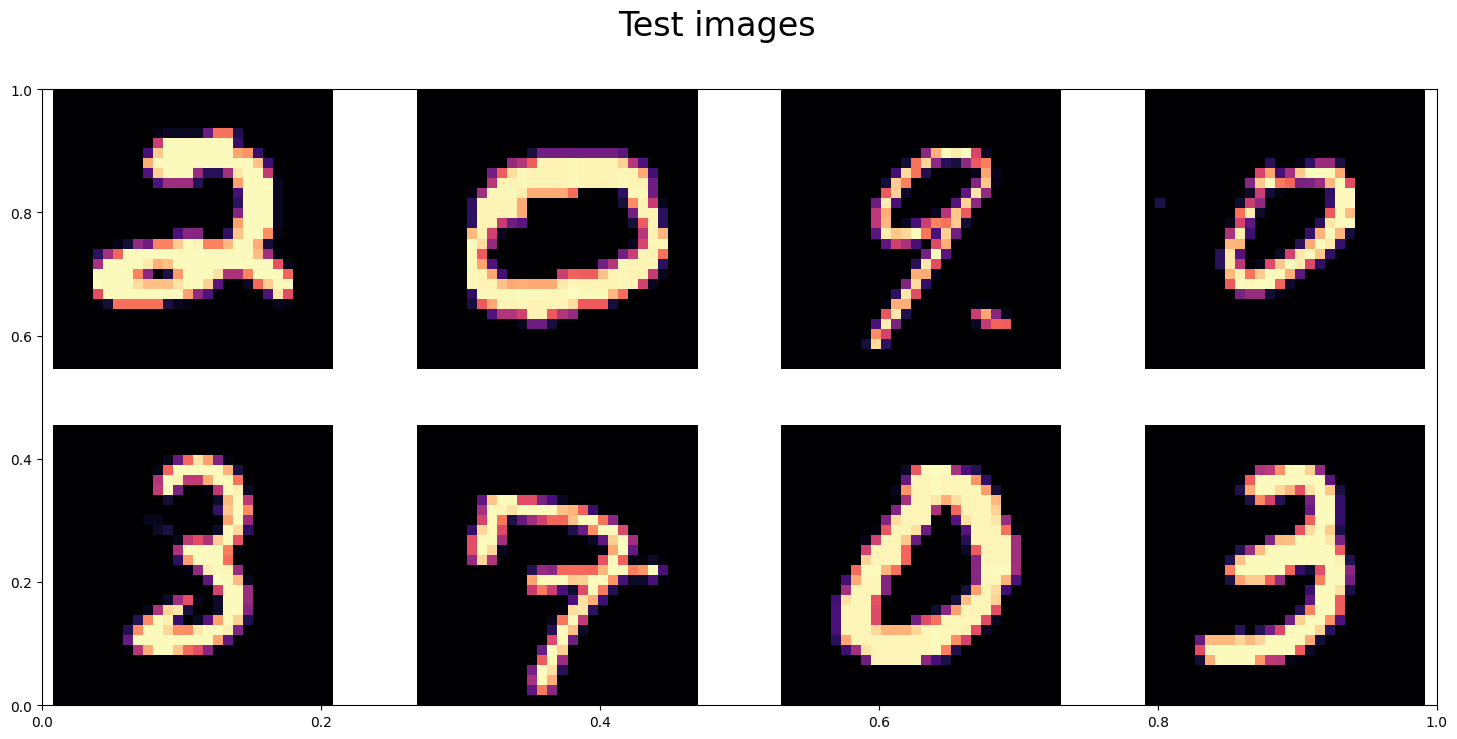

In [9]:
fig, ax=plt.subplots(figsize=(18, 8))
for ind, row in test.iloc[:8, :].iterrows():
    plt.subplot(2, 4, ind+1)
    img=row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('Test images', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

In [10]:
X = train.iloc[:, 1:].to_numpy()
y = train['label'].to_numpy()

test = test.loc[:, :].to_numpy()

for i in (X, y, test):
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


In [11]:
X=X/255.0
test=test/255.0

In [12]:
#reshape dataset
print(X.shape)
print(test.shape)

X=X.reshape(-1,28,28,1)
test=test.reshape(-1,28,28,1)
print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [13]:
#one hot encode target
#shape and value of target
print(y.shape)
print(y[0])
y_enc=to_categorical(y, num_classes=10)
print(y_enc.shape)
print(y_enc[0])

(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:
#train test split
#random seed
randm_seed=2
X_train, X_val, y_train_enc, y_val_enc=train_test_split(X, y_enc, test_size=0.3)
for i in [X_train, y_train_enc, X_val, y_val_enc]:
    print(i.shape)

(29400, 28, 28, 1)
(29400, 10)
(12600, 28, 28, 1)
(12600, 10)


[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


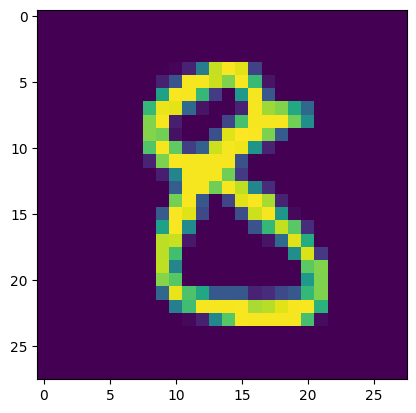

In [15]:
g=plt.imshow(X_train[0][:,:,0])
print(y_train_enc[0])

**MODEL PARAMETERS**

In [16]:
INPUT_SHAPE=(28,28,1)
OUTPUT_SHAPE=10
BATCH_SIZE=128
EPOCHS=18
VERBOSE=2

**Define CNN Model**

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782973595.906062      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782973595.909019      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


**Compile model**

In [18]:
model.compile(optimizer= 'adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history=model.fit(X_train, y_train_enc,
                 epochs=EPOCHS,
                 batch_size=BATCH_SIZE,
                 verbose=VERBOSE,
                 validation_split=0.3)

Epoch 1/18


I0000 00:00:1782973602.809773     110 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 - 10s - 60ms/step - accuracy: 0.7907 - loss: 0.6640 - val_accuracy: 0.9549 - val_loss: 0.1564
Epoch 2/18
161/161 - 1s - 5ms/step - accuracy: 0.9496 - loss: 0.1702 - val_accuracy: 0.9722 - val_loss: 0.0880
Epoch 3/18
161/161 - 1s - 5ms/step - accuracy: 0.9668 - loss: 0.1113 - val_accuracy: 0.9781 - val_loss: 0.0697
Epoch 4/18
161/161 - 1s - 5ms/step - accuracy: 0.9733 - loss: 0.0866 - val_accuracy: 0.9832 - val_loss: 0.0611
Epoch 5/18
161/161 - 1s - 5ms/step - accuracy: 0.9779 - loss: 0.0710 - val_accuracy: 0.9828 - val_loss: 0.0551
Epoch 6/18
161/161 - 1s - 5ms/step - accuracy: 0.9810 - loss: 0.0630 - val_accuracy: 0.9834 - val_loss: 0.0570
Epoch 7/18
161/161 - 1s - 5ms/step - accuracy: 0.9853 - loss: 0.0506 - val_accuracy: 0.9855 - val_loss: 0.0476
Epoch 8/18
161/161 - 1s - 5ms/step - accuracy: 0.9879 - loss: 0.0414 - val_accuracy: 0.9854 - val_loss: 0.0505
Epoch 9/18
161/161 - 1s - 5ms/step - accuracy: 0.9891 - loss: 0.0354 - val_accuracy: 0.9836 - val_loss: 0.0589
Epoch 10/1

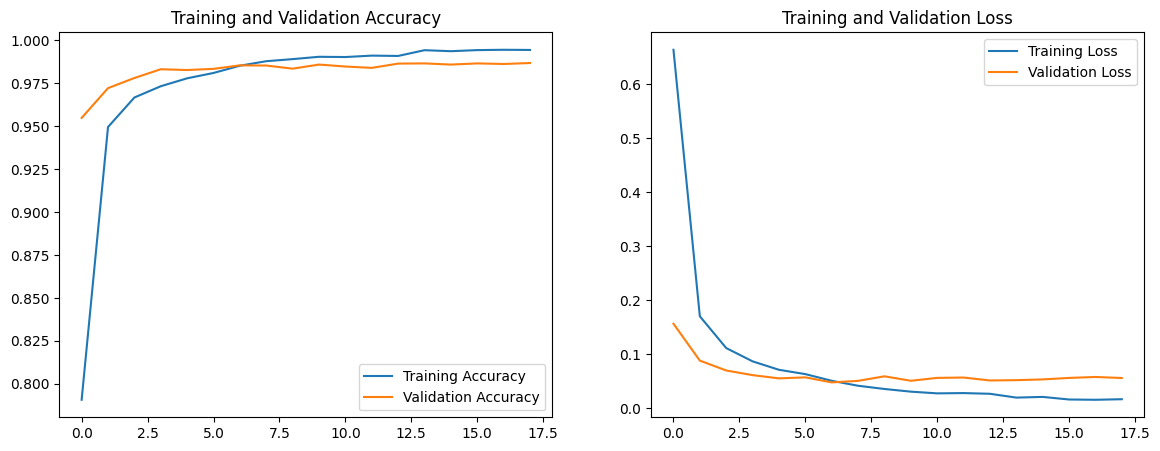

In [21]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.title('Training and Validation Loss')
plt.savefig('./foo.png')
plt.show()

In [22]:
model.evaluate(X_val, y_val_enc, verbose=False)

[0.046547677367925644, 0.9876190423965454]

In [24]:
y_pred_enc=model.predict(X_val)
y_act=[np.argmax(i) for i in y_val_enc]
y_pred=[np.argmax(i) for i in y_pred_enc]
print(y_pred_enc[0])
print(y_pred[0])

394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[4.85524376e-09 8.81191454e-07 9.99999046e-01 8.26764879e-10
 2.78692208e-11 1.07244361e-11 1.12426086e-07 1.65430586e-10
 1.10791480e-10 2.23886868e-14]
2


In [25]:
print(classification_report(y_act, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1258
           1       0.99      0.99      0.99      1391
           2       0.99      0.99      0.99      1240
           3       1.00      0.98      0.99      1262
           4       0.98      0.99      0.98      1244
           5       0.98      0.99      0.99      1171
           6       0.99      0.99      0.99      1236
           7       0.99      0.99      0.99      1318
           8       0.99      0.98      0.99      1171
           9       0.99      0.97      0.98      1309

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



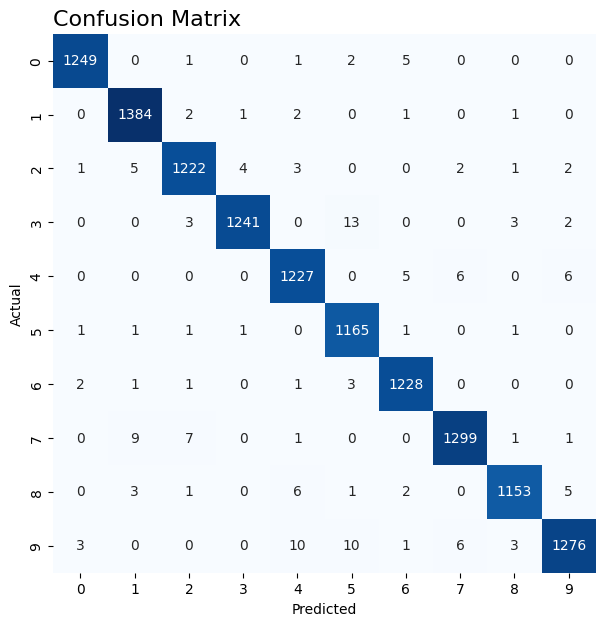

In [30]:
fig, ax=plt.subplots(figsize=(7, 7))
sns.heatmap(confusion_matrix(y_act, y_pred), annot=True,
           cbar=False, fmt='1d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix', loc='left', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [32]:
y_pred_enc=model.predict(test)
y_pred=[np.argmax(i) for i in y_pred_enc]
print(y_pred_enc[0])
print(y_pred[0])

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[2.8951680e-12 3.1130206e-11 1.0000000e+00 6.1615153e-12 5.6094652e-14
 5.9385676e-14 3.7036476e-12 1.4575797e-12 4.6908658e-13 7.0620186e-15]
2


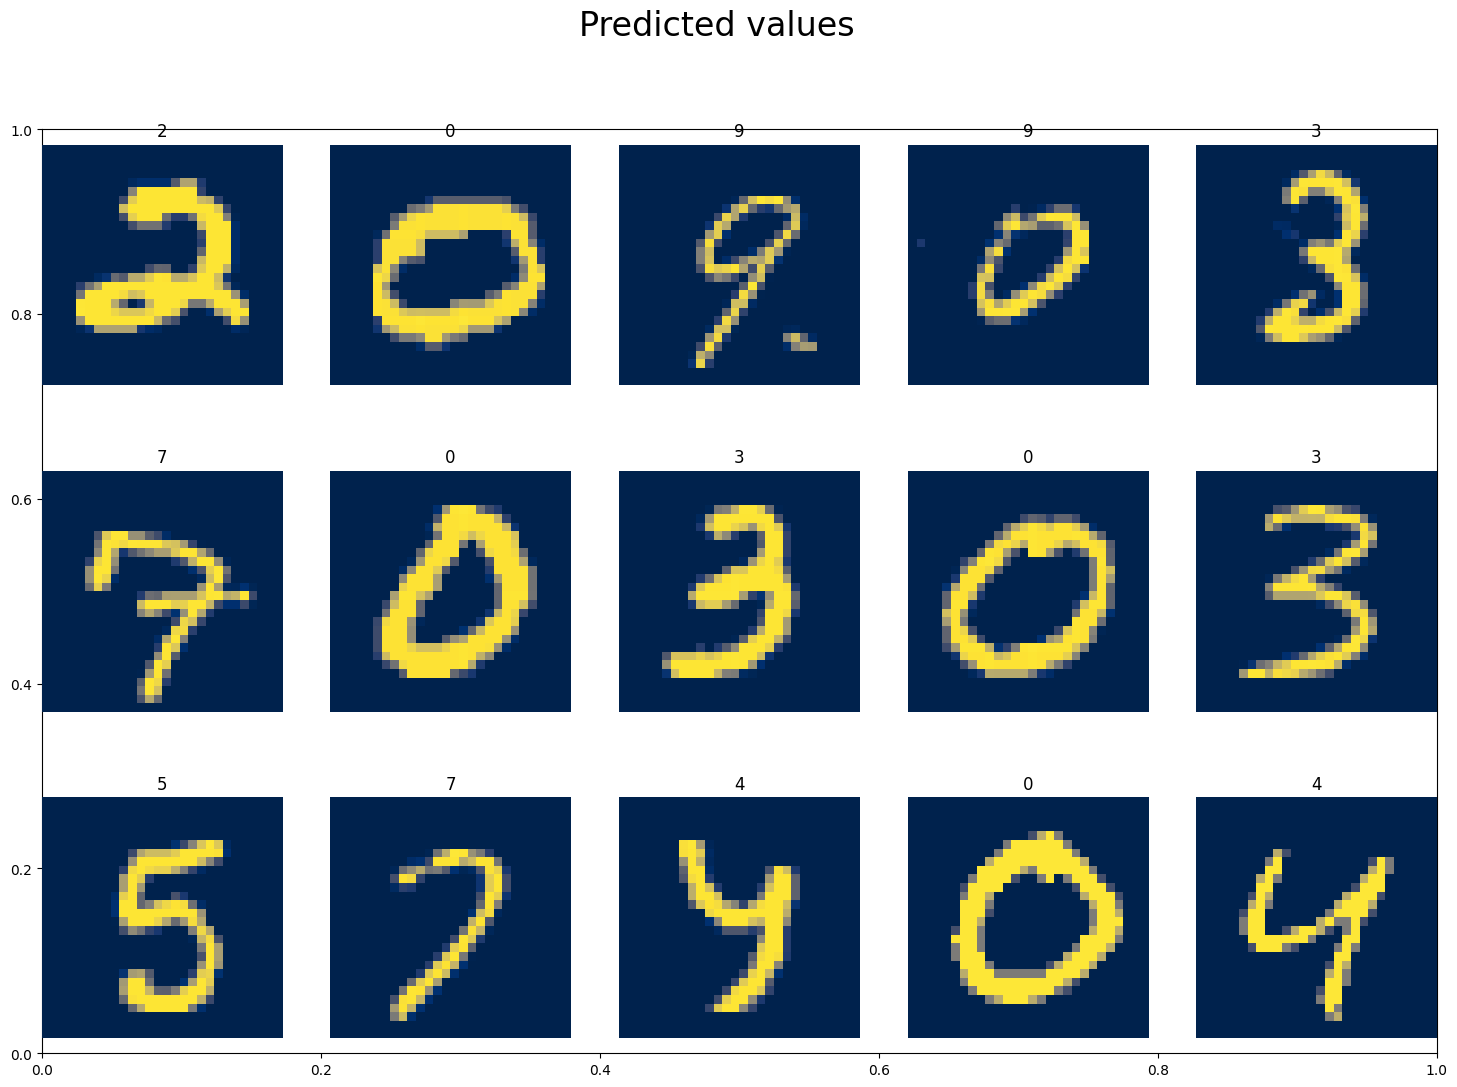

In [36]:
fig, ax = plt.subplots(figsize=(18, 12))
for ind, row in enumerate(test[:15]):
    plt.subplot(3, 5, ind+1)
    plt.title(y_pred[ind])
    img=row.reshape(28, 28)
    fig.suptitle('Predicted values', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='cividis')